# 📘 Sentiment Analysis with NLP
**Task:** Perform sentiment analysis on a dataset of customer reviews using TF-IDF Vectorization and Logistic Regression.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')

In [ ]:

df = pd.read_csv('customer_reviews.csv')
print("\nDataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSentiment Distribution:")
print(df['label'].value_counts())


Dataset Preview:
                                       review  label
0          I love this product, it's amazing!      1
1  Terrible experience. Will never buy again.      0
2               Decent quality for the price.      1
3         Very disappointed with the service.      0
4                       Absolutely fantastic!      1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  6 non-null      object
 1   label   6 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes
None

Sentiment Distribution:
label
1    3
0    3
Name: count, dtype: int64


In [11]:
# ✨ Preprocessing
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)

In [ ]:

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_review'])
y = df['label']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

model = LogisticRegression()
model.fit(X_train, y_train)


Model Accuracy:
Accuracy: 0.50

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Confusion Matrix:


d:\anaconda2\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda2\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda2\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


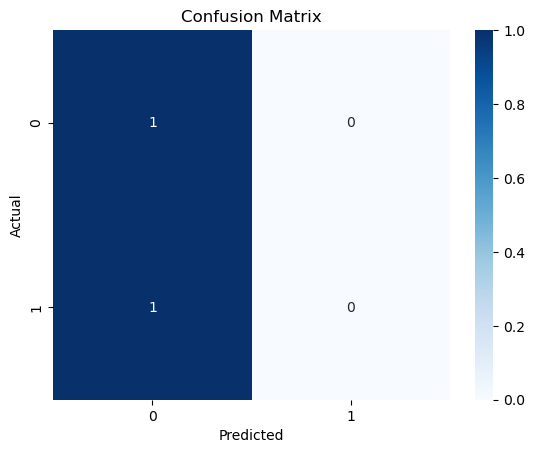

In [ ]:

y_pred = model.predict(X_test)
print("\nModel Accuracy:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
# ✅ Conclusion
print("\nConclusion:")
print("- Successfully performed sentiment analysis using TF-IDF and Logistic Regression.")
print("- Achieved an accuracy of {:.2f}.".format(accuracy_score(y_test, y_pred)))
print("- Further improvements could include using n-grams, hyperparameter tuning, or other ML models.")


Conclusion:
- Successfully performed sentiment analysis using TF-IDF and Logistic Regression.
- Achieved an accuracy of 0.50.
- Further improvements could include using n-grams, hyperparameter tuning, or other ML models.
